<a href="https://colab.research.google.com/github/kunthida-samakhan-kku/Pandas/blob/main/SC663402_Pandas_Review_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


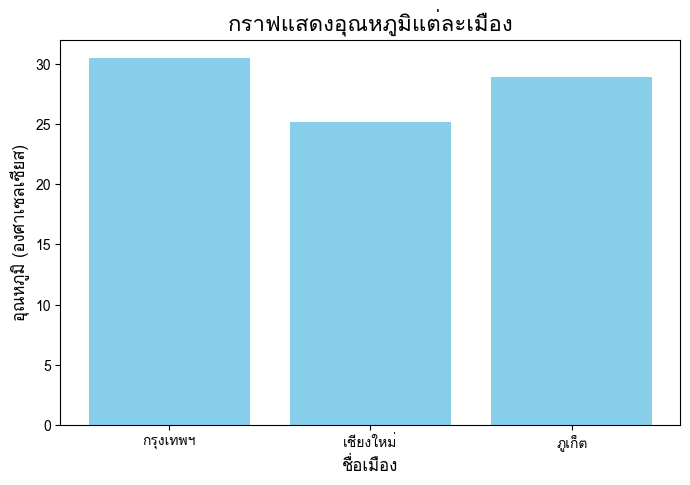

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


### คำตอบข้อ 1

- `s["a"]` ใช้ label ของ index และคืนค่า scalar; `s.iloc[0]` ใช้ตำแหน่งและคืนค่า scalar; `s[["a", "c"]]` เลือกหลาย label และคืน `Series`
- `df["city"]` คืน `Series` ขณะที่ `df[["city"]]` คืน `DataFrame` แม้เลือกคอลัมน์เดียว
- `.loc[0:3]` เป็นการ slice ตาม label และรวมปลายช่วงเมื่อ index เป็นตัวเลขแบบนี้ ส่วน `.iloc[0:3]` เป็นตำแหน่งและไม่รวมตำแหน่ง 3
- `groupby(...).count()` นับเฉพาะค่าที่ไม่เป็นค่าว่างของคอลัมน์ที่ระบุ ส่วน `.size()` นับทุกแถวรวมค่าว่าง
- `groupby(...).mean()` คืน `Series` เมื่อเลือกคอลัมน์เดียว และคืน `DataFrame` เมื่อเลือกคอลัมน์ด้วย `[[...]]`
- การบวก `Series` ใช้ index เป็นตัวจับคู่ ส่วน `to_numpy()` ใช้ตำแหน่งของสมาชิก จึงอาจให้ผลต่างกันเมื่อ index เรียงต่างกัน

แนวปฏิบัติ: ใช้ `.loc/.iloc` ให้ตรงกับความหมายของการเลือกข้อมูล, ใช้ `count/size` ตามนิยามจำนวนที่ต้องการ, และใช้ `Series` หรือ `DataFrame` ให้ตรงกับรูปร่างผลลัพธ์ที่ต้องการ

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
rain_by_city=df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=False)
print(rain_by_city.head(3))
print((rain_by_city/rain_by_city.sum()*100).round(2))
print("เมืองที่สูงกว่าค่าเฉลี่ย:",(rain_by_city>rain_by_city.mean()).sum())


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
city_profile=(df.groupby("city",as_index=False).agg(country=("country","first"),region=("region","first"),n_records=("city","size"),avg_temp=("temperature_c","mean"),total_rain=("rainfall_mm","sum")))
print(city_profile[["city","country","region","n_records","avg_temp","total_rain"]].round(2))


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
weather_import=pd.read_csv(BASE+"world_weather_sample.csv",usecols=["date","city","region","temperature_c","humidity_pct","rainfall_mm"],parse_dates=["date"],na_values=[999,-999],dtype={"city":"category","region":"category"},index_col="city")
print(weather_import.dtypes); weather_import.info()


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
normal=df[["date","city","region","temperature_c","humidity_pct","rainfall_mm"]].memory_usage(deep=True).sum(); compact=weather_import.memory_usage(deep=True).sum()
print("ปกติ:",normal,"compact:",compact,"ลดลง %:",round((normal-compact)/normal*100,2))
print("city/region ลดมากเพราะ category เก็บค่าซ้ำเป็นรหัสแทนข้อความซ้ำ")


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
mx=-np.inf; mn=np.inf; sums={}; counts={}
for ch in pd.read_csv(BASE+"world_weather_sample.csv",chunksize=500,na_values=[999,-999]):
    mx=max(mx,ch.temperature_c.max()); mn=min(mn,ch.temperature_c.min())
    g=ch.groupby("city").temperature_c.agg(["sum","count"])
    for city,r in g.iterrows(): sums[city]=sums.get(city,0)+r["sum"]; counts[city]=counts.get(city,0)+r["count"]
print("max/min:",mx,mn); print(pd.Series(sums)/pd.Series(counts))
print("ต้องสะสม sum และ count เพราะค่าเฉลี่ยของแต่ละ chunk ต้องถ่วงน้ำหนักตามจำนวนข้อมูล")


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
summary=pd.DataFrame({"dtype":df.dtypes.astype(str),"n_missing":df.isna().sum(),"pct_missing":df.isna().mean()*100,"n_unique":df.nunique(),"example_value":df.apply(lambda s:s.dropna().iloc[0] if s.notna().any() else np.nan)}).sort_values("n_missing",ascending=False)
print(summary)


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
bad_t=(~df.temperature_c.between(-60,60))&df.temperature_c.notna(); bad_h=(~df.humidity_pct.between(0,100))&df.humidity_pct.notna()
print(bad_t.sum(),bad_h.sum(),(bad_t|bad_h).sum())


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
c=df.country.astype("string").str.strip().str.casefold(); variants=df.assign(_c=c).groupby("_c").country.agg(lambda s:sorted(s.dropna().unique())); print(variants[variants.map(len)>1])
print("title() อาจทำลายรูปแบบชื่อประเทศที่มีตัวย่อ/การสะกดเฉพาะ; ใช้ strip+casefold แล้ว map ชื่อมาตรฐานแทน")
print("จำนวนประเทศหลัง normalize:",c.nunique())


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
m=df.set_index(["region","city"]).sort_index()
print(m.loc["Asia",["date","temperature_c"]]); print(m.loc[(slice(None),["Tokyo","Bangkok"]),:]); print(m[m.index.get_level_values("city").str.startswith("B")])
print("sort_index ทำให้ MultiIndex เรียงและรองรับการ slice ได้ถูกต้อง")


### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
mask=df.city.eq("Bangkok"); df.loc[mask,"temperature_c"]=0
subset=df.loc[mask].copy(); subset.loc[:,"temperature_c"]=0
print("ใช้ .loc เมื่อแก้ df จริง และใช้ .copy() เมื่อแก้สำเนา เพื่อหลีกเลี่ยง SettingWithCopy")


### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3
mask=df["city"].eq("Bangkok")
# ถ้าต้องการแก้ df จริง
example_df=df.copy()
example_df.loc[mask,"temperature_c"]=0
# ถ้าต้องการแก้เฉพาะสำเนา
subset=df.loc[mask].copy()
subset.loc[:,"temperature_c"]=0
print("ตัวอย่างแก้ df จริงใช้ .loc และงานที่แก้เฉพาะสำเนาใช้ .copy()")
print("หลังจบตัวอย่างยังไม่เปลี่ยน df ต้นฉบับ เพื่อไม่ให้กระทบโจทย์ถัดไป")


---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
x=df.copy(); x["temperature_clean"]=x.temperature_c.where(x.temperature_c.between(-60,60)); p99=x.rainfall_mm.quantile(.99); x["rainfall_capped"]=x.rainfall_mm.mask(x.rainfall_mm>p99,p99); print(x[["temperature_c","temperature_clean","rainfall_mm","rainfall_capped"]].head()); print("p99=",p99)
print("where/mask รักษาแถวไว้ ต่างจากการลบแถวที่ทำให้ข้อมูลสูญหาย")


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
t=df.assign(mu=df.groupby("city").temperature_c.transform("mean")); t["deviation"]=(t.temperature_c-t.mu).abs(); out=t.dropna(subset=["temperature_c"]).sort_values(["city","deviation"],ascending=[True,False]).groupby("city").head(1); print(out[["city","date","temperature_c","deviation"]])


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
df=df.assign(year_month=df.date.dt.to_period("M"),week_of_year=df.date.dt.isocalendar().week,day_name=df.date.dt.day_name(),is_weekend=df.date.dt.dayofweek>=5); print(df[["date","year_month","week_of_year","day_name","is_weekend"]].head())


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
days=pd.date_range(df.date.min(),df.date.max(),freq="D"); obs=pd.DatetimeIndex(df.date.dt.normalize().unique()); print("จำนวนวัน:",len(days),"วันที่ไม่มีข้อมูล:",days.difference(obs).tolist())
print(df.groupby(["region","is_weekend"]).temperature_c.mean().unstack().round(2))
mr=df.groupby(["city",df.date.dt.month]).rainfall_mm.sum(); print(mr.groupby(level=0).idxmax().map(lambda x:x[1]))


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
bkk=df[df.city=="Bangkok"].set_index("date").sort_index().resample("7D").agg(avg_temp=("temperature_c","mean"),total_rain=("rainfall_mm","sum")); print(bkk)
print("resample ใช้ DatetimeIndex เพื่อแบ่งช่วงเวลาแบบต่อเนื่อง เช่น 7 วัน; groupby(month) แบ่งตามหมายเลขเดือน")


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
mp=df.isna().mean().mul(100).sort_values(ascending=False); print(mp.head(1)); cm=df.groupby("city").temperature_c.apply(lambda s:s.isna().mean()*100); print(cm.sort_values(ascending=False)); complete=df.dropna(); loss=(1-complete.city.value_counts().div(df.city.value_counts()).fillna(0))*100; print(len(complete)/len(df)*100,loss.sort_values(ascending=False).head(1))


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
base=df.copy(); gm=base.temperature_c.mean(); citym=base.groupby("city").temperature_c.transform("mean"); prev=base.sort_values(["city","date"]).groupby("city").temperature_c.ffill();
res=pd.DataFrame({"global":base.assign(t=base.temperature_c.fillna(gm)).groupby("city").t.std(),"city_mean":base.assign(t=base.temperature_c.fillna(citym)).groupby("city").t.std(),"previous":base.assign(t=base.temperature_c.fillna(prev)).groupby("city").t.std()}); print(res.round(3)); print("ค่าเฉลี่ยเมืองเหมาะกว่า global เพราะรักษาระดับอากาศของแต่ละเมือง; การเติมค่าเฉลี่ยลดความแปรปรวนมาก")


### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
dup=df.duplicated(["city","date"],keep=False); print("คู่คีย์ซ้ำ:",df.loc[dup,["city","date"]].drop_duplicates().shape[0]); print("ซ้ำทุกคอลัมน์:",df.duplicated().sum()); print(df.loc[dup,["city","date","temperature_c","rainfall_mm"]].head(20)); df=df.drop_duplicates(["city","date"],keep="first").copy(); print("เหลือ:",len(df),"คาดหมาย:",df.city.nunique()*df.date.dt.normalize().nunique())


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 11)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
summary_city=df.groupby("city").agg(avg_temp=("temperature_c","mean"),median_temp=("temperature_c","median"),std_temp=("temperature_c","std"),total_rain=("rainfall_mm","sum"),heavy_rain_days=("rainfall_mm",lambda s:(s>10).sum()),pct_missing_temp=("temperature_c",lambda s:s.isna().mean()*100)); print(summary_city.round(2))


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
df["month"]=df.date.dt.month; rm=df.groupby(["region","month"]).temperature_c.mean().reset_index(name="avg_temp"); print(rm); print("max",rm.loc[rm.avg_temp.idxmax()].to_dict()); print("min",rm.loc[rm.avg_temp.idxmin()].to_dict())


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
c=df.groupby("city").temperature_c.count(); s=df.groupby("city").temperature_c.size(); print(pd.DataFrame({"count":c,"size":s,"difference":s-c})); print("count ไม่นับ NaN แต่ size นับทุกแถว")


---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
rt=df.groupby("city").rainfall_mm.transform("sum"); df["rain_share"]=df.rainfall_mm/rt.replace(0,np.nan); df["temp_z"]=df.groupby("city").temperature_c.transform(lambda s:(s-s.mean())/s.std()); ma=df.groupby(["city",df.date.dt.month]).temperature_c.transform("mean"); df["city_rank_month"]=ma.groupby(df.city).rank(method="dense",ascending=False); print(df.groupby("city").rain_share.sum().round(6))


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
f=df.groupby("city").filter(lambda g:g.temperature_c.notna().sum()>=88); keep=df.groupby("city").temperature_c.transform(lambda s:s.notna().sum()>=88); print("คัดออก:",sorted(set(df.city.unique())-set(f.city.unique()))); print("เหมือนกัน:",f.reset_index(drop=True).equals(df[keep].reset_index(drop=True)))


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
print(df[["city","date","temperature_c","temp_z"]].nlargest(5,"temp_z")); print("z-score ภายในเมืองเหมาะกว่า เพราะแต่ละเมืองมีระดับอุณหภูมิปกติแตกต่างกัน")


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
import time; t=time.perf_counter(); a=df.sort_values(["region","temperature_c"],ascending=[True,False]).groupby("region").head(3); ta=time.perf_counter()-t; t=time.perf_counter(); b=df.groupby("region").apply(lambda g:g.nlargest(3,"temperature_c"),include_groups=False); tb=time.perf_counter()-t; print(a[["region","city","date","temperature_c"]]); print(b); print("เวลา sort+head",ta,"apply+nlargest",tb)


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [ ]:
df["rain_rank_in_city"]=df.groupby("city").rainfall_mm.rank(method="dense",ascending=False); print(df[["city","rainfall_mm","rain_rank_in_city"]].head()); print("average=อันดับเฉลี่ย, min=อันดับแรกของค่าที่เท่ากัน, max=อันดับท้าย, dense=อันดับถัดไปไม่เว้น")


### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
city_order=df.groupby("city").temperature_c.agg(avg_temp="mean",n_observed="count").assign(complete=lambda x:x.n_observed.eq(90)).sort_values(["complete","avg_temp"],ascending=[False,False]); print(city_order)


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [ ]:
h=df.groupby("city").agg(heavy_days=("rainfall_mm",lambda s:(s>10).sum()),observed_days=("rainfall_mm","count")); h["heavy_pct"]=h.heavy_days/h.observed_days*100; print(h.sort_values("heavy_days",ascending=False).head(5)); print(h.sort_values("heavy_pct",ascending=False).head(5)); print("สัดส่วนเหมาะกว่าเมื่อจำนวนวันที่มีข้อมูลต่างกัน")


### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
band=pd.cut(df.temperature_c,[-np.inf,15,20,25,30,np.inf],labels=["<=15","15-20","20-25","25-30",">30"]); print(pd.crosstab(df.region,band)); print(pd.crosstab(df.region,band,normalize="index").round(3)); print(pd.crosstab(df.region,band,normalize="columns").round(3))


### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [ ]:
c=pd.cut(df.temperature_c,bins=4); q=pd.qcut(df.temperature_c,q=4,duplicates="drop"); print(c.value_counts().sort_index()); print(q.value_counts().sort_index()); print("cut แบ่งช่วงกว้างเท่ากันจึงจำนวนไม่เท่ากัน; qcut แบ่งตาม quantile จึงจำนวนใกล้กัน")


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
piv=pd.pivot_table(df,index="city",columns="month",values="rainfall_mm",aggfunc="sum",margins=True,margins_name="Total",fill_value=0); print(piv); print("สูงสุด:",piv.drop(index="Total")["Total"].idxmax())


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [ ]:
g=df.groupby(["city","month"]).rainfall_mm.sum().unstack(fill_value=0); g["Total"]=g.sum(axis=1); g.loc["Total"]=g.sum(); print(g); print("ตรงกับ pivot:",np.allclose(piv.drop(index="Total").drop(columns="Total").sort_index(axis=1),g.drop(index="Total").drop(columns="Total").sort_index(axis=1)))


### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
w=piv.drop(index="Total").drop(columns="Total").reset_index().melt(id_vars="city",var_name="month",value_name="rainfall_mm"); print(w.head()); print("long เหมาะกับ tidy data/analysis; wide เหมาะกับการนำเสนอเป็นตาราง")


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
mw=df.groupby(["region","city","month"])[["temperature_c","rainfall_mm"]].mean().unstack("month"); mw=mw.swaplevel(0,1,axis=1).sort_index(axis=1); print(mw.loc["Asia"].xs(2,level="month",axis=1))


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 13) -> (2070, 15)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 14)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1
m1 = df.merge(city_info, on="city", how="left", suffixes=("", "_city"))
merged_all = m1.merge(region_info, on="region", how="left", suffixes=("", "_region"))
print("shape เดิม:", df.shape, "-> หลัง merge:", merged_all.shape)
print("คอลัมน์ที่มี suffix:", [c for c in merged_all.columns if c.endswith("_city") or c.endswith("_region")])
print("\nอุณหภูมิเฉลี่ยตาม timezone")
if "timezone" in merged_all.columns:
    print(merged_all.groupby("timezone")["temperature_c"].mean().sort_values(ascending=False))
print("\nอุณหภูมิเฉลี่ยตาม continent_code")
if "continent_code" in merged_all.columns:
    print(merged_all.groupby("continent_code")["temperature_c"].mean().sort_values(ascending=False))

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [ ]:
# คำตอบข้อ 14.2
city_dup = pd.concat([city_info, city_info.iloc[[0]]], ignore_index=True)
merged_dup = df.merge(city_dup, on="city", how="left")
print("จำนวนแถวเดิม:", len(df), "หลังเพิ่ม city ซ้ำ:", len(merged_dup), "เพิ่มขึ้น:", len(merged_dup)-len(df))
old_rain = df["rainfall_mm"].sum()
new_rain = merged_dup["rainfall_mm"].sum()
print("ฝนรวมเดิม:", old_rain, "ฝนรวมใหม่:", new_rain)
print("ฝนรวมเปลี่ยนแปลง:", (new_rain-old_rain)/old_rain*100, "%")
try:
    df.merge(city_dup[["city", "timezone"]], on="city", how="left", validate="many_to_one")
except Exception as e:
    print("validate='many_to_one' ตรวจพบปัญหา:", type(e).__name__, "-", e)
print("คำอธิบาย: duplicate key ทำให้แถวฝั่งซ้ายถูกจับคู่หลายครั้ง เกิดการคูณจำนวนแถวและทำให้ aggregate เช่น rainfall ถูกนับซ้ำโดยไม่จำเป็น ซึ่งอันตรายเพราะผลลัพธ์ยังดูเหมือนเป็นตารางปกติ")

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3
bad_city = city_info.copy()
bad_city.loc[0, "city"] = " " + str(bad_city.loc[0, "city"]).upper() + " "
bad_city.loc[1, "city"] = str(bad_city.loc[1, "city"]).lower()
check_bad = df.merge(bad_city[["city", "population_millions"]], on="city", how="left", indicator=True)
print(check_bad["_merge"].value_counts())
print("\nตัวอย่างแถวที่จับคู่ไม่สำเร็จ:")
print(check_bad.loc[check_bad["_merge"].eq("left_only"), ["city", "_merge"]].drop_duplicates().head())

# ทำความสะอาด key ก่อน merge
left_clean = df.assign(city_key=df["city"].astype("string").str.strip().str.casefold())
right_clean = bad_city.assign(city_key=bad_city["city"].astype("string").str.strip().str.casefold())
fixed = left_clean.merge(right_clean[["city_key", "population_millions"]], on="city_key", how="left", indicator=True)
print("\nหลัง normalize key:")
print(fixed["_merge"].value_counts())

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [ ]:
# คำตอบข้อ 14.4
left = df.set_index("city")
city_right = city_info.set_index("city")
joined = left.join(city_right, how="left", rsuffix="_city")
joined = (joined.reset_index()
               .merge(region_info, on="region", how="left", suffixes=("", "_region")))
print(joined.shape)
print(joined.groupby("timezone")["temperature_c"].mean().sort_values(ascending=False) if "timezone" in joined.columns else joined.head())
print("\nคำอธิบาย: join สะดวกเมื่อมี key อยู่ใน index และต้องการเติมคอลัมน์จากตารางอีกฝั่ง แต่ยืดหยุ่นน้อยกว่า merge เมื่อ key อยู่คนละคอลัมน์หรือมีหลายเงื่อนไข")

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 13)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 13)
(1357, 12)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 15.1


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 15.2


### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [ ]:
# คำตอบข้อ 15.4


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1
conditions = [
    (df["temperature_c"] >= 30) & (df["humidity_pct"] >= 70) & (df["rainfall_mm"] <= 1),
    (df["rainfall_mm"] > 10) & (df["humidity_pct"] >= 70),
    (df["wind_speed_kmh"] > 25) & (df["rainfall_mm"] <= 10),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]

def flag_apply(row):
    if conditions[0].loc[row.name]: return "ร้อนชื้น"
    if conditions[1].loc[row.name]: return "ฝนหนัก"
    if conditions[2].loc[row.name]: return "ลมแรง"
    return "ปกติ"

import time
start = time.perf_counter()
flag1 = df.apply(flag_apply, axis=1)
time_apply = time.perf_counter() - start
start = time.perf_counter()
flag2 = pd.Series(np.select(conditions, choices, default="ปกติ"), index=df.index)
time_select = time.perf_counter() - start
start = time.perf_counter()
flag3 = pd.Series(np.where(conditions[0], "ร้อนชื้น",
                  np.where(conditions[1], "ฝนหนัก",
                  np.where(conditions[2], "ลมแรง", "ปกติ"))), index=df.index)
time_where = time.perf_counter() - start

print("apply == np.select:", flag1.equals(flag2))
print("np.select == np.where:", flag2.equals(flag3))
print("เวลา apply:", time_apply, "s")
print("เวลา np.select:", time_select, "s")
print("เวลา np.where ซ้อน:", time_where, "s")
print("เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุด:", max(time_apply,time_select,time_where)/min(time_apply,time_select,time_where), "เท่า")
df["weather_flag"] = flag2

### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [ ]:
# คำตอบข้อ 16.2
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF", "North America": "NA", "South America": "SA", "Oceania": "OC"}
df["region_code"] = df["region"].map(region_code)
print(df[["region", "region_code"]].drop_duplicates().sort_values("region"))
print("\napply บน Series เหมาะกับการส่งแต่ละค่าเข้า function ที่อาจมีตรรกะซับซ้อน ส่วน map เหมาะกับการแทนค่าตาม mapping/dict โดยตรง")
print("ค่าที่ไม่มีใน dict จะกลายเป็น NaN; หากต้องการค่าเริ่มต้นสามารถใช้ .fillna('UNKNOWN') หลัง map")

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [ ]:
# คำตอบข้อ 16.3
# สูตรอย่างง่ายที่กำหนดเอง: heat_index = temperature + 0.05 * humidity

def heat_index(temp, humidity):
    return temp + 0.05 * humidity

df["heat_index_apply"] = df.apply(lambda row: heat_index(row["temperature_c"], row["humidity_pct"]), axis=1)
df["heat_index_vectorized"] = heat_index(df["temperature_c"], df["humidity_pct"])
print(df[["temperature_c", "humidity_pct", "heat_index_apply", "heat_index_vectorized"]].head())
print("ผลตรงกัน:", np.allclose(df["heat_index_apply"].fillna(-999), df["heat_index_vectorized"].fillna(-999)))
print("คำอธิบาย: วิธีที่สองทำงานได้เพราะฟังก์ชันใช้การคำนวณที่รองรับ pandas Series/NumPy แบบ element-wise หากฟังก์ชันใช้เฉพาะ operations ที่รับ scalar เช่น math.sqrt โดยไม่รองรับ Series วิธีส่งทั้ง Series อาจใช้ไม่ได้")

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

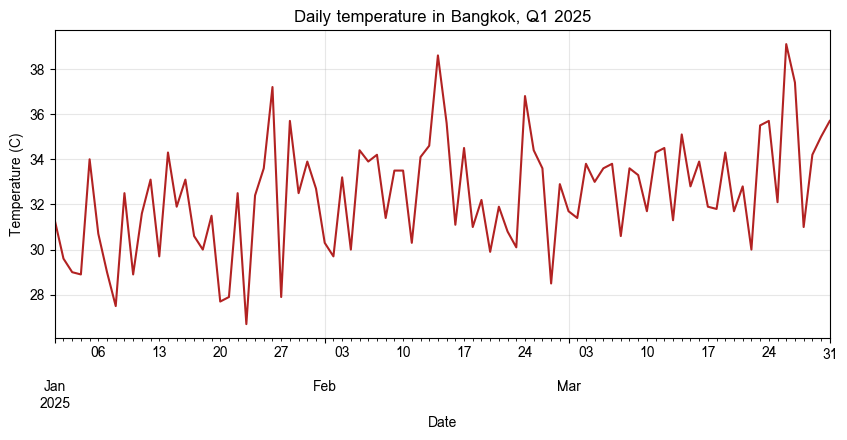

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

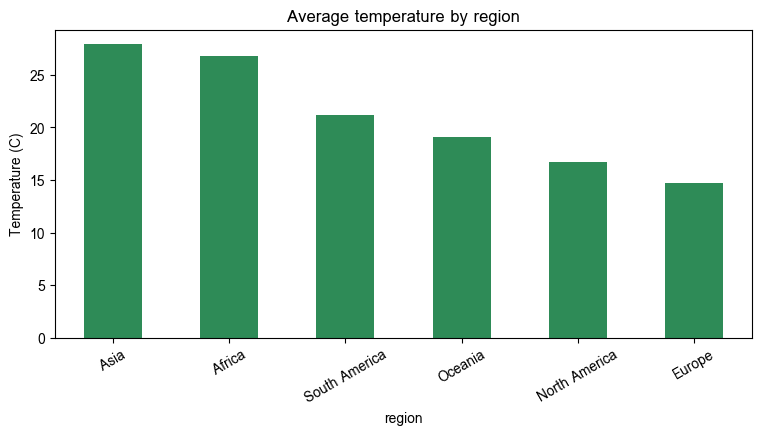

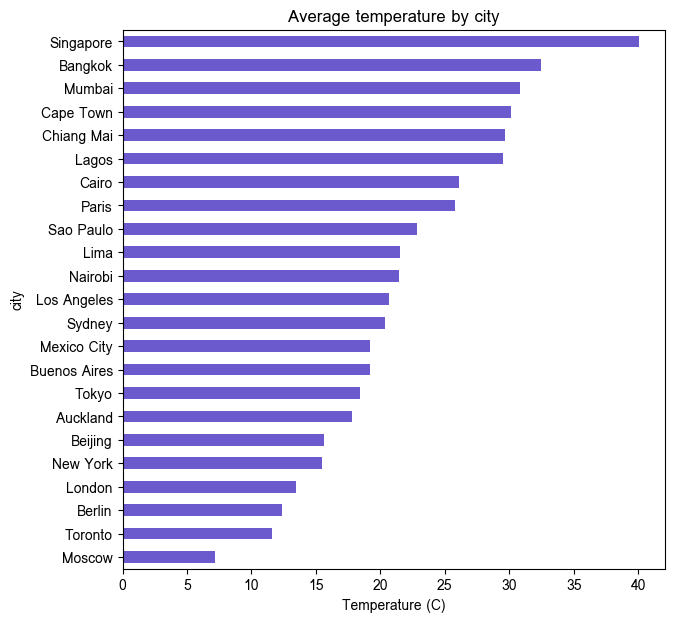

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

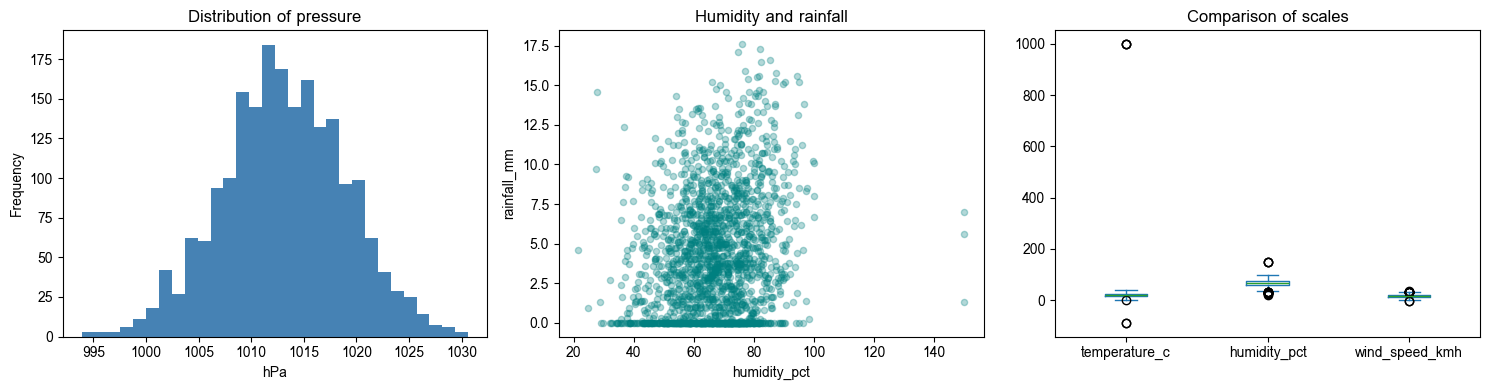

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

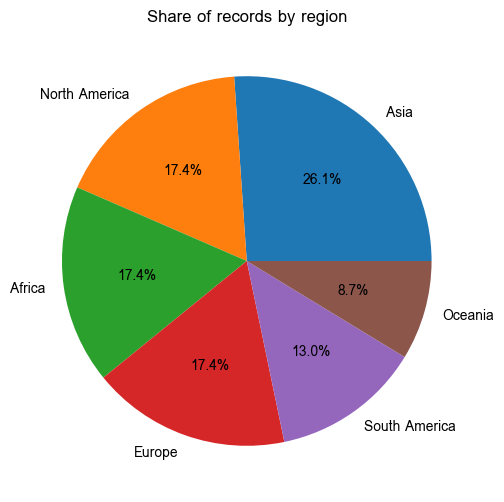

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

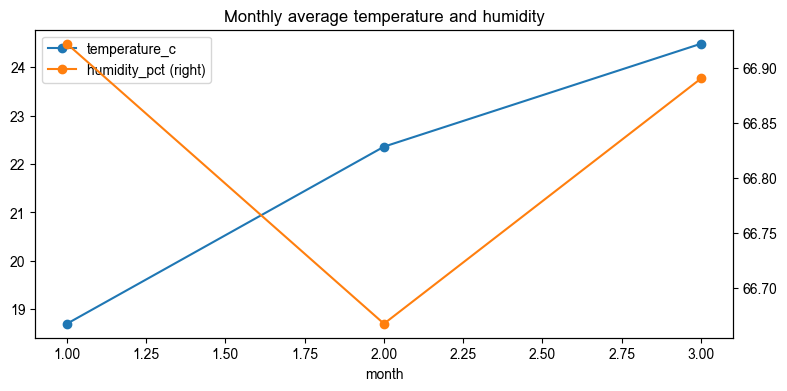

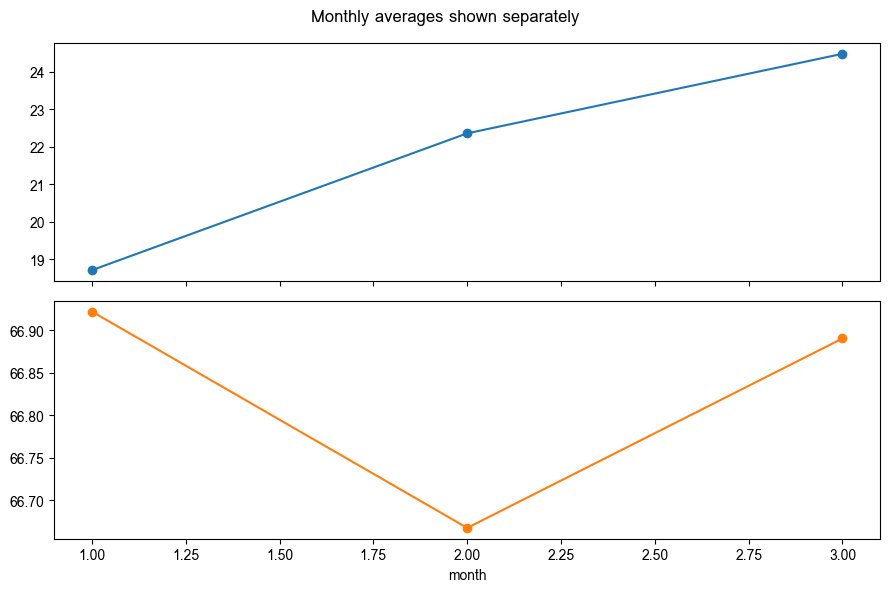

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

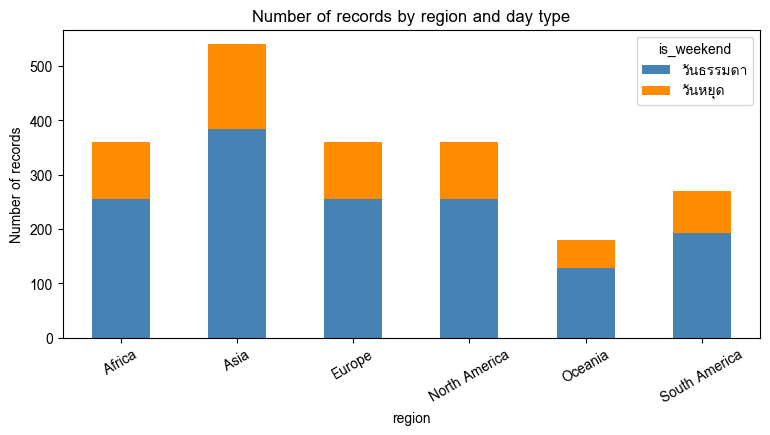

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

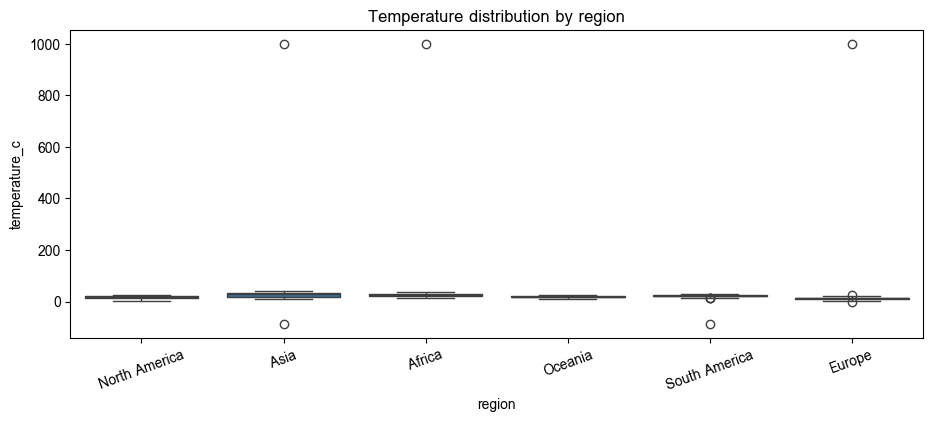

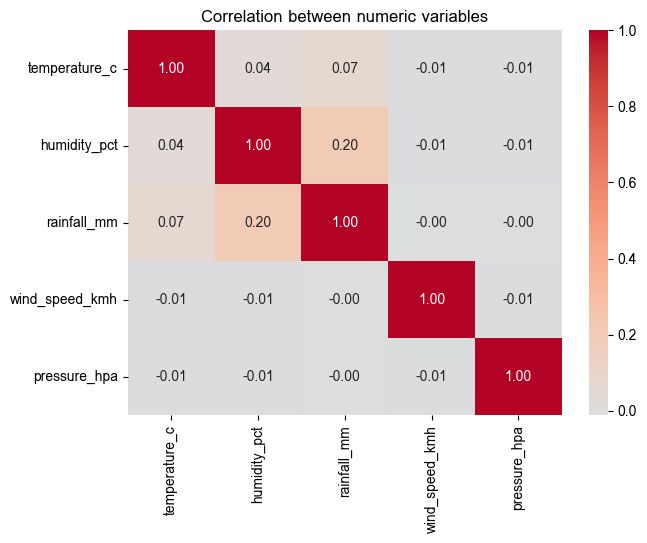

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

In [ ]:
three=["Bangkok","Tokyo","London"]; fig,ax=plt.subplots(figsize=(10,5)); [df[df.city.eq(c)].sort_values("date").plot(x="date",y="temperature_c",ax=ax,label=c) for c in three]; ax.set(title="Daily temperature: 3 cities",xlabel="Date",ylabel="Temperature (C)"); ax.legend(); plt.show()
fig,ax=plt.subplots(figsize=(8,8)); df.groupby("city").rainfall_mm.sum().sort_values().plot.barh(ax=ax); ax.set(title="Total rainfall by city",xlabel="Rainfall (mm)",ylabel="City"); plt.show()
fig,ax=plt.subplots(figsize=(8,4)); df.wind_speed_kmh.plot.hist(bins=20,ax=ax); ax.set(title="Wind speed distribution (bins=20)",xlabel="Wind speed (km/h)",ylabel="Frequency"); plt.show(); print("bins น้อยเห็นภาพหยาบ; bins มากเห็นรายละเอียดมากขึ้นแต่ noise อาจมากขึ้น")
cp=df.groupby("city").temperature_c.mean().to_frame("avg_temp").join(city_info.set_index("city")["population_millions"]); fig,ax=plt.subplots(figsize=(7,5)); cp.plot.scatter(x="population_millions",y="avg_temp",ax=ax); ax.set(title="Population vs average temperature",xlabel="Population (millions)",ylabel="Average temperature (C)"); plt.show()


### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(15,10)); three=["Bangkok","Tokyo","London"]; [df[df.city.eq(c)].sort_values("date").plot(x="date",y="temperature_c",ax=axes[0,0],label=c) for c in three]; axes[0,0].set_title("Daily temperature: 3 cities"); axes[0,0].legend(); df.groupby("city").rainfall_mm.sum().sort_values().plot.barh(ax=axes[0,1]); axes[0,1].set_title("Total rainfall by city"); df.wind_speed_kmh.plot.hist(bins=20,ax=axes[1,0]); axes[1,0].set_title("Wind speed distribution"); cp.plot.scatter(x="population_millions",y="avg_temp",ax=axes[1,1]); axes[1,1].set_title("Population vs average temperature"); plt.suptitle("Weather Data Overview"); plt.tight_layout(); plt.show()


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

In [ ]:
df["rain_band"]=pd.cut(df.rainfall_mm,[-.001,1,5,10,np.inf],labels=["<=1","1-5","5-10",">10"]); tab=pd.crosstab(df.region,df.rain_band); fig,ax=plt.subplots(figsize=(10,5)); tab.plot.bar(stacked=True,ax=ax); ax.set(title="Rainfall categories by region (stacked)",xlabel="Region",ylabel="Days"); plt.show(); fig,ax=plt.subplots(figsize=(10,5)); tab.plot.bar(stacked=False,ax=ax); ax.set(title="Rainfall categories by region (grouped)",xlabel="Region",ylabel="Days"); plt.show(); print("stacked เหมาะกับองค์ประกอบรวม; grouped เหมาะกับการเปรียบเทียบแต่ละหมวดข้ามภูมิภาค")


### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

In [ ]:
analysis=df.merge(city_info[["city","population_millions"]],on="city",how="left"); fig,ax=plt.subplots(figsize=(10,5)); sns.boxplot(data=analysis,x="region",y="rainfall_mm",hue="is_weekend",ax=ax); ax.set_title("Rainfall by region and weekend"); plt.show(); cols=["temperature_c","humidity_pct","rainfall_mm","population_millions"]; fig,ax=plt.subplots(figsize=(7,5)); sns.heatmap(analysis[cols].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0,ax=ax); ax.set_title("Correlation matrix"); plt.show(); print("correlation ใกล้ +1/-1 คือความสัมพันธ์เชิงเส้นสูง แต่ไม่ใช่หลักฐานเหตุและผล")


---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [ ]:
q1=df[df.date.dt.month.isin([1,2,3])]; city_std=q1.groupby(["region","city"]).temperature_c.std().reset_index(name="city_std"); reg=q1.groupby("region").temperature_c.std().sort_values(ascending=False); print(reg); r=reg.index[0]; print("ภูมิภาคสูงสุด:",r); print(city_std[city_std.region.eq(r)].sort_values("city_std",ascending=False))


2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [ ]:
h=df.groupby("city").agg(heavy_days=("rainfall_mm",lambda s:(s>10).sum()),observed=("rainfall_mm","count")); h["heavy_pct"]=h.heavy_days/h.observed*100; print("ตามสัดส่วน
",h.sort_values("heavy_pct",ascending=False).head(5)); print("ตามจำนวนวัน
",h.sort_values("heavy_days",ascending=False).head(5)); print("สัดส่วนเหมาะกว่าเมื่อจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากัน")


3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [ ]:
x=df.groupby("city").agg(avg_temp=("temperature_c","mean"),avg_rain=("rainfall_mm","mean")).join(city_info.set_index("city")["population_millions"]); print(x[["population_millions","avg_temp","avg_rain"]].corr()); print("ควรระวัง: correlation ไม่ได้แปลว่าเป็นเหตุเป็นผล และระดับข้อมูลมีเพียง 23 เมือง")


4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [ ]:
m=df.assign(month=df.date.dt.month).groupby(["region",df.date.dt.month]).agg(avg_rain=("rainfall_mm","mean"),heavy_rate=("rainfall_mm",lambda s:(s>10).mean()),avg_wind=("wind_speed_kmh","mean")).reset_index();
for c in ["avg_rain","heavy_rate","avg_wind"]:
 lo,hi=m[c].min(),m[c].max(); m[c+"_score"]=(m[c]-lo)/(hi-lo) if hi!=lo else 0
m["risk_score"]=.5*m.heavy_rate_score+.3*m.avg_rain_score+.2*m.avg_wind_score; worst=m.loc[m.groupby("region").risk_score.idxmax()]; print(worst[["region","month","avg_rain","heavy_rate","avg_wind","risk_score"]].round(3)); print("เกณฑ์ให้น้ำหนักฝนหนัก 50% ฝนเฉลี่ย 30% และลม 20% เพราะเป็นตัวแปรที่มีในข้อมูลและสะท้อนอุปสรรคต่อการเดินทางโดยตรง")


---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️